# Moving spheres using the Vedo library 

In [ ]:
!pip -q install vedo

In [ ]:
import vedo
vedo.settings.init_colab()

## Create animation

In [3]:
import os
import glob
import numpy as np
import vedo
from vedo import Plotter, Sphere, Plane, Box

# Force VTK backend (important in Colab)
vedo.settings.default_backend = "vtk"

# -----------------------------
# Clear frames
# -----------------------------
frames_dir = "frames"
os.makedirs(frames_dir, exist_ok=True)

for f in glob.glob(os.path.join(frames_dir, "*.png")):
    os.remove(f)

print("Old frames cleared.")

# -----------------------------
# Scene geometry
# -----------------------------
sphere_radius = 0.5

# Floor (horizontal, Z-up)
plane = Plane(
    pos=(0, 0, 0),
    normal=(0, 0, 1),
    s=(20, 20)
).c((0.95, 0.95, 0.9)).lighting("glossy")


# -----------------------------
# Wall with window (robust boolean)
# -----------------------------

# Main wall
wall_body = Box(
    pos=(4, 0, 3),
    size=(0.5, 8, 6)
).triangulate()

# Window cutter (thicker in X so it fully cuts through)
window_cut = Box(
    pos=(4, 0, 3.5),
    size=(2.0, 3, 2.5)   # thickness must be > wall thickness
).triangulate()

# Boolean subtraction
wall = wall_body.boolean("minus", window_cut)

# Important cleanup
wall.clean().compute_normals()

wall.c("yellow").lighting("glossy")

# Spheres
sphere_blue = Sphere(r=sphere_radius, res=48)\
    .c("royalblue").lighting("glossy")

sphere_red = Sphere(r=sphere_radius, res=48)\
    .c("red").lighting("glossy")

# -----------------------------
# Plotter
# -----------------------------
plt_vtk = Plotter(offscreen=True, size=(600, 600), bg="white")

plt_vtk.show(plane, wall, sphere_blue, sphere_red, resetcam=True)

# Camera setup (Z-up world)
plt_vtk.camera.SetViewUp(0, 0, 1)
plt_vtk.camera.SetPosition(20, -20, 15)
plt_vtk.camera.SetFocalPoint(0, 0, 0)

plt_vtk.renderer.ResetCameraClippingRange()

# -----------------------------
# Animation
# -----------------------------
n_frames = 120
radius_path = 6

for i in range(n_frames):
    angle = 2 * np.pi * i / n_frames

    # Blue sphere
    xb = radius_path * np.cos(angle)
    yb = radius_path * np.sin(angle)
    sphere_blue.pos(xb, yb, sphere_radius)

    # Red sphere opposite side
    xr = radius_path * np.cos(angle + np.pi)
    yr = radius_path * np.sin(angle + np.pi)
    sphere_red.pos(xr, yr, sphere_radius)

    plt_vtk.render()
    plt_vtk.screenshot(f"{frames_dir}/frame_{i:03d}.png")

plt_vtk.close()

print("Frames saved.")

Old frames cleared.
Frames saved.


## Show animation sequence as a grid

Displaying frame grid preview...


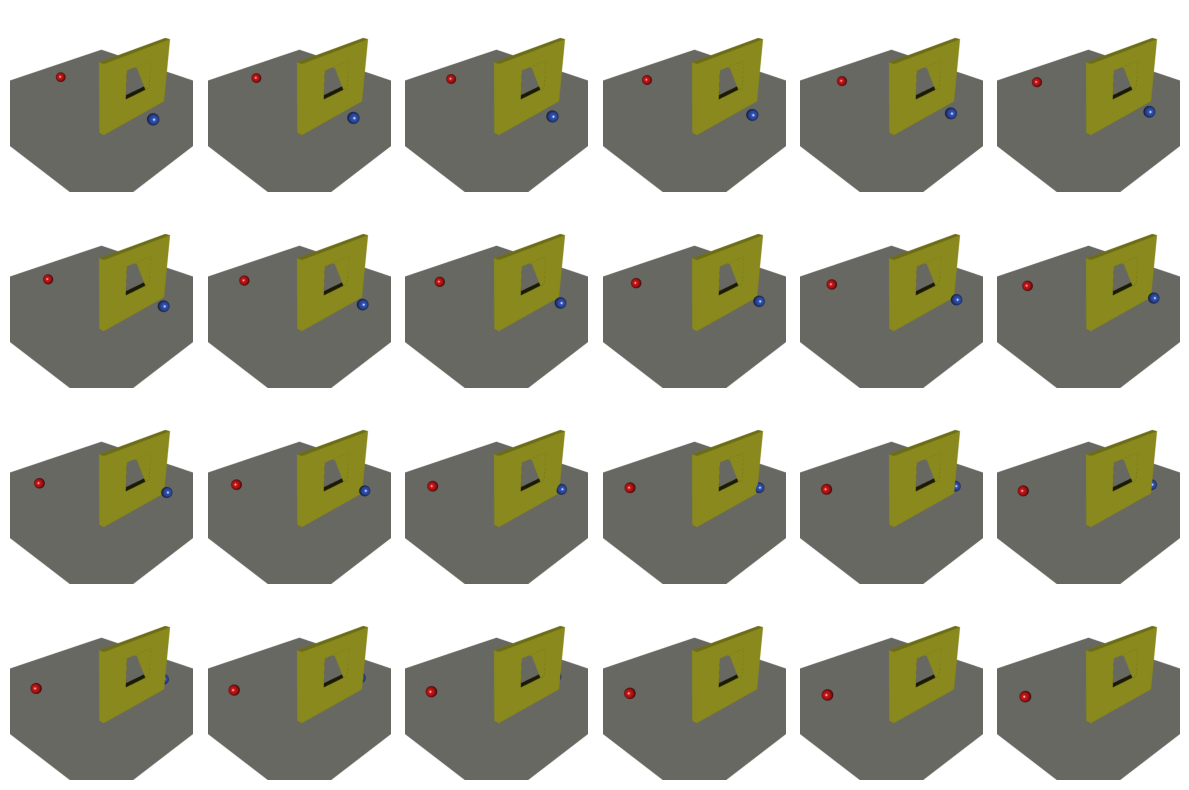

In [6]:
from PIL import Image

# -----------------------------
# SETTINGS
# -----------------------------
GRID_ROWS = 4
GRID_COLS = 6


# -----------------------------
# Show grid preview
# -----------------------------
print("Displaying frame grid preview...")

from PIL import Image
import matplotlib.pyplot as plt

frame_files = sorted(glob.glob(f"{frames_dir}/frame_*.png"))
total = min(GRID_ROWS * GRID_COLS, len(frame_files))

fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(12, 8))

for i in range(GRID_ROWS * GRID_COLS):
    ax = axes.flat[i]
    ax.axis("off")

    if i < total:
        img = Image.open(frame_files[i])
        ax.imshow(img)

plt.tight_layout()
plt.show()

## Create video file

In [8]:
# -----------------------------
# Create video
# -----------------------------
!ffmpeg -loglevel error -y -framerate 30 -i frames/frame_%03d.png \
        -c:v libx264 -pix_fmt yuv420p -movflags +faststart spheres.mp4

print("Video created: spheres.mp4")

Video created: spheres.mp4


## Display video

In [ ]:
from IPython.display import HTML
from base64 import b64encode

video_path = 'spheres.mp4'
# Read the file and encode it
mp4 = open(video_path, 'rb').read()
decoded_vid = "data:video/mp4;base64," + b64encode(mp4).decode()

# Embed in an HTML video tag
HTML(f'<video width=500 controls><source src={decoded_vid} type="video/mp4"></video>')